# TP1 - Systèmes de recommandation

**Master Sciences des Données - Université Abdelmalek Essaâdi, ENS Tétouan**  
**Jeu de données : MovieLens Latest Small**

Réponses aux questions **1.a à 1.o** : matrice d'utilité, filtrage
user-based et item-based, RMSE, NDCG@10, SVD, choix du rang et
correction du biais utilisateur. Le notebook est autoportant dans Colab et
utilise une graine aléatoire fixée à 42.

## Préparation

Les fonctions demandées sont définies ci-dessous. Le zéro code une valeur
manquante et n'entre jamais dans le calcul des moyennes de notes.

In [1]:
"""Outils pédagogiques pour les TP MovieLens.

Le module privilégie des implémentations explicites, reproductibles et proches
des formules des sujets. Les zéros représentent exclusivement des notes
manquantes ; les moyennes sont donc calculées sur les valeurs observées.
"""

from __future__ import annotations

import os
import urllib.request
import zipfile
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, pairwise_distances


SEED = 42
EPS = 1e-12


def _download_and_extract(url: str, archive_path: Path, target_parent: Path) -> None:
    """Télécharge puis extrait une archive MovieLens si elle est absente."""
    target_parent.mkdir(parents=True, exist_ok=True)
    if not archive_path.exists():
        print(f"Téléchargement de {url}")
        urllib.request.urlretrieve(url, archive_path)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(target_parent)


def ensure_ml_latest_small() -> Path:
    """Retourne le dossier ml-latest-small, localement ou dans Colab."""
    override = os.environ.get("ML_LATEST_SMALL_DIR")
    if override and (Path(override) / "ratings.csv").exists():
        return Path(override)
    root = Path("/content/data") if Path("/content").exists() else Path("data")
    folder = root / "ml-latest-small"
    if not (folder / "ratings.csv").exists():
        _download_and_extract(
            "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip",
            root / "ml-latest-small.zip",
            root,
        )
    return folder


def ensure_ml100k() -> Path:
    """Retourne le dossier ml-100k, localement ou dans Colab."""
    override = os.environ.get("ML_100K_DIR")
    if override and (Path(override) / "u.data").exists():
        return Path(override)
    root = Path("/content/data") if Path("/content").exists() else Path("data")
    folder = root / "ml-100k"
    if not (folder / "u.data").exists():
        _download_and_extract(
            "https://files.grouplens.org/datasets/movielens/ml-100k.zip",
            root / "ml-100k.zip",
            root,
        )
    return folder


def build_utility_matrix(
    frame: pd.DataFrame,
    user_col: str,
    item_col: str,
    rating_col: str,
    users: np.ndarray | None = None,
    items: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict, dict]:
    """Construit une matrice utilisateur-item et les deux mappings d'indices."""
    users = np.sort(frame[user_col].unique()) if users is None else np.asarray(users)
    items = np.sort(frame[item_col].unique()) if items is None else np.asarray(items)
    user_to_idx = {value: idx for idx, value in enumerate(users)}
    item_to_idx = {value: idx for idx, value in enumerate(items)}
    utility = np.zeros((len(users), len(items)), dtype=np.float32)
    u_idx = frame[user_col].map(user_to_idx).to_numpy()
    i_idx = frame[item_col].map(item_to_idx).to_numpy()
    utility[u_idx, i_idx] = frame[rating_col].to_numpy(dtype=np.float32)
    return utility, users, items, user_to_idx, item_to_idx


def dataframe_to_triplets(
    frame: pd.DataFrame,
    user_to_idx: dict,
    item_to_idx: dict,
    user_col: str,
    item_col: str,
    rating_col: str,
) -> np.ndarray:
    """Convertit un dataframe en tableau (index_user, index_item, note)."""
    return np.column_stack(
        [
            frame[user_col].map(user_to_idx).to_numpy(dtype=np.int32),
            frame[item_col].map(item_to_idx).to_numpy(dtype=np.int32),
            frame[rating_col].to_numpy(dtype=np.float32),
        ]
    )


def load_latest_small(
    data_dir: Path,
    train_fraction: float = 0.80,
    seed: int = SEED,
) -> dict:
    """Charge MovieLens Latest Small et applique le split global demandé."""
    ratings = pd.read_csv(Path(data_dir) / "ratings.csv")
    movies = pd.read_csv(Path(data_dir) / "movies.csv")
    users = np.sort(ratings.userId.unique())
    items = np.sort(ratings.movieId.unique())
    shuffled = ratings.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    split = int(len(shuffled) * train_fraction)
    train_df = shuffled.iloc[:split].copy()
    test_df = shuffled.iloc[split:].copy()
    utility, users, items, user_to_idx, item_to_idx = build_utility_matrix(
        train_df, "userId", "movieId", "rating", users=users, items=items
    )
    test_set = dataframe_to_triplets(
        test_df, user_to_idx, item_to_idx, "userId", "movieId", "rating"
    )
    return {
        "ratings": ratings,
        "movies": movies,
        "train_df": train_df,
        "test_df": test_df,
        "utility": utility,
        "mask": utility != 0,
        "test_set": test_set,
        "users": users,
        "items": items,
        "user_to_idx": user_to_idx,
        "item_to_idx": item_to_idx,
    }


def load_ml100k(data_dir: Path) -> dict:
    """Charge MovieLens 100K et construit la matrice complète."""
    columns = ["user_id", "item_id", "rating", "timestamp"]
    ratings = pd.read_csv(Path(data_dir) / "u.data", sep="\t", names=columns)
    utility, users, items, user_to_idx, item_to_idx = build_utility_matrix(
        ratings, "user_id", "item_id", "rating"
    )
    item_columns = [
        "movie_id", "movie_title", "release_date", "video_release_date", "IMDb_URL",
        "unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
        "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
        "Romance", "Sci-Fi", "Thriller", "War", "Western",
    ]
    movies = pd.read_csv(
        Path(data_dir) / "u.item",
        sep="|",
        names=item_columns,
        encoding="latin-1",
    )
    return {
        "ratings": ratings,
        "movies": movies,
        "utility": utility,
        "users": users,
        "items": items,
        "user_to_idx": user_to_idx,
        "item_to_idx": item_to_idx,
    }


def observed_means(matrix: np.ndarray, axis: int) -> np.ndarray:
    """Moyenne par ligne/colonne en ignorant les zéros manquants."""
    mask = matrix != 0
    sums = matrix.sum(axis=axis, dtype=np.float64)
    counts = mask.sum(axis=axis)
    global_mean = float(matrix[mask].mean()) if np.any(mask) else 0.0
    return np.divide(
        sums,
        counts,
        out=np.full_like(sums, global_mean, dtype=np.float64),
        where=counts > 0,
    ).astype(np.float32)


def center_observed(matrix: np.ndarray, axis: int = 1) -> tuple[np.ndarray, np.ndarray]:
    """Centre uniquement les notes observées et préserve les zéros manquants."""
    mask = matrix != 0
    means = observed_means(matrix, axis=axis)
    if axis == 1:
        centered = np.where(mask, matrix - means[:, None], 0.0)
    else:
        centered = np.where(mask, matrix - means[None, :], 0.0)
    return centered.astype(np.float32), means


def get_similarities(utility: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Produits scalaires users/items et inverses de normes, sans boucle."""
    matrix = np.asarray(utility, dtype=np.float32)
    user_products = matrix @ matrix.T
    item_products = matrix.T @ matrix
    user_norms = np.sqrt(np.clip(np.diag(user_products), 0, None))
    item_norms = np.sqrt(np.clip(np.diag(item_products), 0, None))
    inv_user_norm = np.divide(
        1.0, user_norms, out=np.zeros_like(user_norms), where=user_norms > EPS
    )
    inv_item_norm = np.divide(
        1.0, item_norms, out=np.zeros_like(item_norms), where=item_norms > EPS
    )
    return user_products, item_products, inv_user_norm, inv_item_norm


def cosine_from_products(products: np.ndarray, inv_norm: np.ndarray) -> np.ndarray:
    """Transforme une matrice de produits scalaires en similarités cosinus."""
    return (products * inv_norm[:, None] * inv_norm[None, :]).astype(np.float32)


def rank_users(id_user: int, similarities: np.ndarray, inv_norm: np.ndarray) -> list[tuple[int, float]]:
    scores = similarities[id_user] * inv_norm[id_user] * inv_norm
    order = np.argsort(scores)[::-1]
    return [(int(idx), float(scores[idx])) for idx in order if idx != id_user]


def rank_items(id_movie: int, similarities: np.ndarray, inv_norm: np.ndarray) -> list[tuple[int, float]]:
    scores = similarities[id_movie] * inv_norm[id_movie] * inv_norm
    order = np.argsort(scores)[::-1]
    return [(int(idx), float(scores[idx])) for idx in order if idx != id_movie]


def _weighted_average(values: np.ndarray, weights: np.ndarray, fallback: float) -> float:
    denominator = float(np.abs(weights).sum())
    if denominator <= EPS:
        return float(fallback)
    return float(np.dot(weights, values) / denominator)


def recommend_user_based_item(
    id_user: int,
    id_item: int,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    mask: np.ndarray | None = None,
    baseline: float = 0.0,
) -> float:
    """Prédit une note via les k utilisateurs les plus proches ayant noté l'item."""
    mask = utility != 0 if mask is None else mask
    scores = similarities[id_user] * inv_norm[id_user] * inv_norm
    candidates = np.flatnonzero(mask[:, id_item])
    candidates = candidates[candidates != id_user]
    if candidates.size == 0:
        return float(baseline)
    order = candidates[np.argsort(scores[candidates])[::-1][:k]]
    return _weighted_average(utility[order, id_item], scores[order], baseline)


def recommend_item_based_item(
    id_user: int,
    id_item: int,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    mask: np.ndarray | None = None,
    baseline: float = 0.0,
) -> float:
    """Prédit une note via les k items les plus proches déjà notés."""
    mask = utility != 0 if mask is None else mask
    scores = similarities[id_item] * inv_norm[id_item] * inv_norm
    candidates = np.flatnonzero(mask[id_user])
    candidates = candidates[candidates != id_item]
    if candidates.size == 0:
        return float(baseline)
    order = candidates[np.argsort(scores[candidates])[::-1][:k]]
    return _weighted_average(utility[id_user, order], scores[order], baseline)


def precompute_topk(
    products: np.ndarray,
    inv_norm: np.ndarray,
    k: int,
    block_size: int = 512,
) -> tuple[np.ndarray, np.ndarray]:
    """Pré-calcul des k voisins cosinus par blocs, sans dupliquer toute la matrice."""
    n = products.shape[0]
    k = min(k, max(1, n - 1))
    indices = np.empty((n, k), dtype=np.int32)
    weights = np.empty((n, k), dtype=np.float32)
    for start in range(0, n, block_size):
        stop = min(n, start + block_size)
        scores = products[start:stop] * inv_norm[start:stop, None] * inv_norm[None, :]
        rows = np.arange(stop - start)
        scores[rows, np.arange(start, stop)] = -np.inf
        part = np.argpartition(scores, -k, axis=1)[:, -k:]
        part_scores = np.take_along_axis(scores, part, axis=1)
        order = np.argsort(part_scores, axis=1)[:, ::-1]
        indices[start:stop] = np.take_along_axis(part, order, axis=1)
        weights[start:stop] = np.take_along_axis(part_scores, order, axis=1)
    return indices, weights


def predict_user_topk_matrix(
    utility: np.ndarray,
    mask: np.ndarray,
    neighbor_indices: np.ndarray,
    neighbor_weights: np.ndarray,
    baselines: np.ndarray | None = None,
) -> np.ndarray:
    """Matrice complète des prédictions user-based avec dénominateur observé."""
    predictions = np.empty_like(utility, dtype=np.float32)
    for user in range(utility.shape[0]):
        idx = neighbor_indices[user]
        weights = neighbor_weights[user][:, None]
        values = utility[idx]
        observed = mask[idx]
        numerator = (weights * values).sum(axis=0)
        denominator = (np.abs(weights) * observed).sum(axis=0)
        row = np.divide(
            numerator,
            denominator,
            out=np.zeros_like(numerator, dtype=np.float32),
            where=denominator > EPS,
        )
        if baselines is not None:
            row += baselines[user]
        predictions[user] = row
    return predictions


def predict_item_topk_matrix(
    utility: np.ndarray,
    mask: np.ndarray,
    neighbor_indices: np.ndarray,
    neighbor_weights: np.ndarray,
    baselines: np.ndarray | None = None,
) -> np.ndarray:
    """Matrice complète des prédictions item-based avec dénominateur observé."""
    predictions = np.empty_like(utility, dtype=np.float32)
    for user in range(utility.shape[0]):
        values = utility[user, neighbor_indices]
        observed = mask[user, neighbor_indices]
        numerator = (neighbor_weights * values).sum(axis=1)
        denominator = (np.abs(neighbor_weights) * observed).sum(axis=1)
        row = np.divide(
            numerator,
            denominator,
            out=np.zeros_like(numerator, dtype=np.float32),
            where=denominator > EPS,
        )
        if baselines is not None:
            row += baselines[user]
        predictions[user] = row
    return predictions


def rmse_from_matrix(test_set: np.ndarray, predictions: np.ndarray) -> float:
    users = test_set[:, 0].astype(np.int32)
    items = test_set[:, 1].astype(np.int32)
    actual = test_set[:, 2].astype(np.float32)
    pred = np.clip(predictions[users, items], 0.5, 5.0)
    return float(np.sqrt(mean_squared_error(actual, pred)))


def get_rmse_user_based(
    test_set: np.ndarray,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    mask: np.ndarray | None = None,
    baselines: np.ndarray | None = None,
) -> float:
    """RMSE demandée pour l'approche orientée utilisateurs."""
    mask = utility != 0 if mask is None else mask
    values = []
    for user, item, _ in test_set:
        user, item = int(user), int(item)
        baseline = 0.0 if baselines is None else float(baselines[user])
        values.append(
            recommend_user_based_item(
                user, item, utility, similarities, inv_norm, k, mask, baseline
            )
        )
    pred = np.clip(np.asarray(values), 0.5, 5.0)
    return float(np.sqrt(mean_squared_error(test_set[:, 2], pred)))


def get_rmse_item_based(
    test_set: np.ndarray,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    mask: np.ndarray | None = None,
    baselines: np.ndarray | None = None,
) -> float:
    """RMSE demandée pour l'approche orientée items."""
    mask = utility != 0 if mask is None else mask
    values = []
    for user, item, _ in test_set:
        user, item = int(user), int(item)
        baseline = 0.0 if baselines is None else float(baselines[user])
        values.append(
            recommend_item_based_item(
                user, item, utility, similarities, inv_norm, k, mask, baseline
            )
        )
    pred = np.clip(np.asarray(values), 0.5, 5.0)
    return float(np.sqrt(mean_squared_error(test_set[:, 2], pred)))


def ndcg_at_k_from_matrix(
    test_set: np.ndarray,
    predictions: np.ndarray,
    train_mask: np.ndarray,
    k: int = 10,
) -> float:
    """NDCG@k moyen ; les items d'entraînement sont exclus du classement."""
    by_user: dict[int, dict[int, float]] = defaultdict(dict)
    for user, item, rating in test_set:
        by_user[int(user)][int(item)] = float(rating)
    values = []
    for user, relevant in by_user.items():
        scores = predictions[user].astype(np.float64, copy=True)
        scores[train_mask[user]] = -np.inf
        width = min(k, np.isfinite(scores).sum())
        if width == 0:
            continue
        top = np.argpartition(scores, -width)[-width:]
        top = top[np.argsort(scores[top])[::-1]]
        relevance = np.array([relevant.get(int(item), 0.0) for item in top])
        discounts = np.log2(np.arange(2, width + 2))
        dcg = float(np.sum((np.power(2.0, relevance) - 1.0) / discounts))
        ideal_rel = np.sort(np.fromiter(relevant.values(), dtype=float))[::-1][:width]
        ideal_discounts = np.log2(np.arange(2, len(ideal_rel) + 2))
        idcg = float(np.sum((np.power(2.0, ideal_rel) - 1.0) / ideal_discounts))
        if idcg > 0:
            values.append(dcg / idcg)
    return float(np.mean(values))


def get_ndcg_at_k_user_based(
    test_set: np.ndarray,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    k_ndcg: int = 10,
    mask: np.ndarray | None = None,
    baselines: np.ndarray | None = None,
) -> float:
    mask = utility != 0 if mask is None else mask
    idx, weights = precompute_topk(similarities, inv_norm, k)
    pred = predict_user_topk_matrix(utility, mask, idx, weights, baselines)
    return ndcg_at_k_from_matrix(test_set, pred, mask, k_ndcg)


def get_ndcg_at_k_item_based(
    test_set: np.ndarray,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    k_ndcg: int = 10,
    mask: np.ndarray | None = None,
    baselines: np.ndarray | None = None,
) -> float:
    mask = utility != 0 if mask is None else mask
    idx, weights = precompute_topk(similarities, inv_norm, k)
    pred = predict_item_topk_matrix(utility, mask, idx, weights, baselines)
    return ndcg_at_k_from_matrix(test_set, pred, mask, k_ndcg)


def svd_decompose(utility: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """SVD NumPy réduite ; la troncature au rang N est faite ensuite."""
    return np.linalg.svd(utility.astype(np.float32), full_matrices=False)


def svd_predict(
    components: tuple[np.ndarray, np.ndarray, np.ndarray],
    rank: int,
    baselines: np.ndarray | None = None,
) -> np.ndarray:
    u, singular_values, vt = components
    rank = min(rank, len(singular_values))
    pred = (u[:, :rank] * singular_values[:rank]) @ vt[:rank]
    if baselines is not None:
        pred = pred + baselines[:, None]
    return pred.astype(np.float32)


def get_rmse_svd(
    test_set: np.ndarray,
    utility: np.ndarray,
    N: int = 100,
    baselines: np.ndarray | None = None,
    components: tuple[np.ndarray, np.ndarray, np.ndarray] | None = None,
) -> float:
    components = svd_decompose(utility) if components is None else components
    return rmse_from_matrix(test_set, svd_predict(components, N, baselines))


def get_ndcg_svd(
    test_set: np.ndarray,
    utility: np.ndarray,
    k_ndcg: int = 10,
    N: int = 100,
    baselines: np.ndarray | None = None,
    mask: np.ndarray | None = None,
    components: tuple[np.ndarray, np.ndarray, np.ndarray] | None = None,
) -> float:
    mask = utility != 0 if mask is None else mask
    components = svd_decompose(utility) if components is None else components
    pred = svd_predict(components, N, baselines)
    return ndcg_at_k_from_matrix(test_set, pred, mask, k_ndcg)


def train_test_split_per_user(
    ratings: np.ndarray,
    n_test: int = 10,
    seed: int = SEED,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Retire n_test notes par utilisateur, de manière déterministe."""
    rng = np.random.default_rng(seed)
    train = ratings.copy()
    test = np.zeros_like(ratings)
    triplets = []
    for user in range(ratings.shape[0]):
        observed = np.flatnonzero(ratings[user])
        chosen = rng.choice(observed, size=min(n_test, len(observed)), replace=False)
        test[user, chosen] = ratings[user, chosen]
        train[user, chosen] = 0.0
        triplets.extend((user, int(item), float(ratings[user, item])) for item in chosen)
    assert not np.any((train != 0) & (test != 0))
    return train, test, np.asarray(triplets, dtype=np.float32)


def fast_similarity(ratings: np.ndarray, kind: str = "user") -> np.ndarray:
    """Similarité cosinus vectorisée pour le TP2."""
    vectors = ratings if kind == "user" else ratings.T
    products = vectors @ vectors.T
    norms = np.sqrt(np.clip(np.diag(products), 0, None))
    inv = np.divide(1.0, norms, out=np.zeros_like(norms), where=norms > EPS)
    return (products * inv[:, None] * inv[None, :]).astype(np.float32)


def predict_fast_simple(ratings: np.ndarray, similarity: np.ndarray, kind: str = "user") -> np.ndarray:
    """Version matricielle de la première prédiction naïve du TP2."""
    denominator = np.abs(similarity).sum(axis=1)
    if kind == "user":
        pred = similarity @ ratings
        return np.divide(
            pred,
            denominator[:, None],
            out=np.zeros_like(pred),
            where=denominator[:, None] > EPS,
        )
    pred = ratings @ similarity
    return np.divide(
        pred,
        denominator[None, :],
        out=np.zeros_like(pred),
        where=denominator[None, :] > EPS,
    )


def mse_on_observed(pred: np.ndarray, actual: np.ndarray) -> float:
    mask = actual != 0
    return float(mean_squared_error(actual[mask], np.clip(pred[mask], 0.5, 5.0)))


def rmse_on_observed(pred: np.ndarray, actual: np.ndarray) -> float:
    return float(np.sqrt(mse_on_observed(pred, actual)))


def top_k_movies(
    similarity: np.ndarray,
    titles: dict[int, str],
    movie_idx: int,
    k: int = 6,
) -> list[str]:
    order = np.argsort(similarity[movie_idx])[::-1]
    order = [int(idx) for idx in order if idx != movie_idx][:k]
    return [titles[idx] for idx in order]


def pearson_item_similarity(train: np.ndarray) -> np.ndarray:
    similarity = 1.0 - pairwise_distances(train.T, metric="correlation")
    similarity = np.nan_to_num(similarity, nan=0.0, posinf=0.0, neginf=0.0)
    return similarity.astype(np.float32)

In [2]:
import gc, json, platform, time
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
OUTPUT_DIR = Path(os.environ.get("TP_OUTPUT_DIR", "artifacts"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Python :", platform.python_version())
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)

Python : 3.12.13
NumPy  : 2.5.2
Pandas : 3.0.5


## Questions 1.a et 1.b - Chargement et matrice d'utilité

`load_latest_small()` lit `ratings.csv`, attribue des indices contigus à partir
de zéro, mélange les lignes et réalise le split global 80 % / 20 % demandé.

In [3]:
data_dir = ensure_ml_latest_small()
data = load_latest_small(data_dir, train_fraction=0.80, seed=SEED)
ratings, movies = data["ratings"], data["movies"]
utility, train_mask, test_set = data["utility"], data["mask"], data["test_set"]
item_ids = data["items"]
density = 100 * train_mask.sum() / train_mask.size
print(f"Dossier              : {data_dir}")
print(f"Évaluations          : {len(ratings):,}")
print(f"Utilisateurs / films : {utility.shape[0]} / {utility.shape[1]}")
print(f"Train / test         : {len(data['train_df']):,} / {len(data['test_df']):,}")
print(f"Densité train        : {density:.3f} %")
display(ratings.head())

Dossier              : /workspace/scratch/77eb318ef56f/tmp/source_data/latest_repo/aula0/ml-latest-small
Évaluations          : 100,836
Utilisateurs / films : 610 / 9724
Train / test         : 80,668 / 20,168
Densité train        : 1.360 %


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


**Réponse.** La matrice est très creuse. Le zéro signifie « note inconnue » et
ne doit pas être confondu avec une mauvaise note.

## Question 1.c - Similarité cosinus

$$\operatorname{sim}_{cos}(x,y)=\frac{x^Ty}{\lVert x\rVert_2\lVert y\rVert_2}.$$

Les quatre sorties demandées sont calculées par opérations matricielles, sans
boucle Python : produits utilisateurs, produits films et inverses des normes.

In [4]:
start = time.perf_counter()
user_products, item_products, inv_user_norm, inv_item_norm = get_similarities(utility)
similarity_time = time.perf_counter() - start
print("Produits utilisateurs :", user_products.shape)
print("Produits films        :", item_products.shape)
print(f"Temps de calcul       : {similarity_time:.2f} s")

Produits utilisateurs : (610, 610)
Produits films        : (9724, 9724)
Temps de calcul       : 0.70 s


## Question 1.d - Classement des utilisateurs et des films

In [5]:
title_by_id = dict(zip(movies.movieId, movies.title))
top_users = rank_users(0, user_products, inv_user_norm)[:5]
top_items = rank_items(0, item_products, inv_item_norm)[:5]
display(pd.DataFrame(top_users, columns=["user_index", "similarité"]))
display(pd.DataFrame([
    {"film": title_by_id[item_ids[idx]], "similarité": score}
    for idx, score in top_items
]))

,user_index,similarité
0,56,0.323751
1,265,0.291972
2,312,0.290708
3,90,0.282137
4,327,0.277529


,film,similarité
0,Toy Story 2 (1999),0.480705
1,Groundhog Day (1993),0.466411
2,Independence Day (a.k.a. ID4) (1996),0.460878
3,Mission: Impossible (1996),0.453501
4,"Shawshank Redemption, The (1994)",0.448133


## Questions 1.e et 1.f - Prédiction pondérée

User-based retient les utilisateurs proches ayant noté le film ; item-based
retient les films proches déjà notés. Le score est une moyenne pondérée par les
similarités.

In [6]:
example_user, example_item, example_rating = test_set[0]
example_user, example_item = int(example_user), int(example_item)
global_mean = float(utility[train_mask].mean())
p_user = recommend_user_based_item(
    example_user, example_item, utility, user_products, inv_user_norm,
    k=10, mask=train_mask, baseline=global_mean)
p_item = recommend_item_based_item(
    example_user, example_item, utility, item_products, inv_item_norm,
    k=10, mask=train_mask, baseline=global_mean)
print("Note réelle             :", float(example_rating))
print(f"Prédiction user-based   : {np.clip(p_user, .5, 5):.3f}")
print(f"Prédiction item-based   : {np.clip(p_item, .5, 5):.3f}")

Note réelle             : 3.5
Prédiction user-based   : 3.260
Prédiction item-based   : 3.241


## Questions 1.g et 1.h - RMSE

$$\operatorname{RMSE}=\sqrt{\frac{1}{n}\sum_{j=1}^n(\hat r_j-r_j)^2}.$$

Les dix voisins sont pré-calculés afin d'évaluer efficacement les 20 % de
notes réservées au test.

In [7]:
user_idx10, user_w10 = precompute_topk(user_products, inv_user_norm, 10)
item_idx10, item_w10 = precompute_topk(item_products, inv_item_norm, 10)
pred_user_raw = predict_user_topk_matrix(
    utility, train_mask, user_idx10, user_w10)
pred_item_raw = predict_item_topk_matrix(
    utility, train_mask, item_idx10, item_w10)
# Si aucun voisin n'a noté l'item, repli sur la moyenne globale.
pred_user_raw[pred_user_raw == 0] = global_mean
pred_item_raw[pred_item_raw == 0] = global_mean
raw_cf_metrics = {
    "User-based k=10": rmse_from_matrix(test_set, pred_user_raw),
    "Item-based k=10": rmse_from_matrix(test_set, pred_item_raw),
}
display(pd.DataFrame.from_dict(raw_cf_metrics, orient="index", columns=["RMSE"]))

,RMSE
User-based k=10,1.060962
Item-based k=10,0.997426


## Questions 1.i et 1.j - NDCG@10

La NDCG mesure la qualité de l'ordre des recommandations. Les films du train
sont exclus du classement et l'idéal place d'abord les meilleures notes du test.

In [8]:
raw_cf_ndcg = {
    "User-based k=10": ndcg_at_k_from_matrix(test_set, pred_user_raw, train_mask, 10),
    "Item-based k=10": ndcg_at_k_from_matrix(test_set, pred_item_raw, train_mask, 10),
}
display(pd.DataFrame.from_dict(raw_cf_ndcg, orient="index", columns=["NDCG@10"]))

,NDCG@10
User-based k=10,0.023340
Item-based k=10,0.027532


## Questions 1.k à 1.m - SVD, rang optimal et NDCG

NumPy calcule $R=U\Sigma V^T$. La reconstruction au rang $N$ conserve les $N$
plus grandes valeurs singulières. La décomposition est calculée une seule fois.

In [9]:
start = time.perf_counter()
raw_svd = svd_decompose(utility)
raw_svd_time = time.perf_counter() - start
ranks = [5, 10, 20, 40, 60, 80, 100, 150, 200]
raw_svd_rmse = {
    rank: rmse_from_matrix(test_set, svd_predict(raw_svd, rank))
    for rank in ranks
}
best_raw_rank = min(raw_svd_rmse, key=raw_svd_rmse.get)
pred_svd_raw = svd_predict(raw_svd, best_raw_rank)
raw_svd_ndcg = ndcg_at_k_from_matrix(test_set, pred_svd_raw, train_mask, 10)
print(f"Temps SVD brute     : {raw_svd_time:.2f} s")
print(f"Meilleur rang brut  : {best_raw_rank}")
print(f"RMSE minimale       : {raw_svd_rmse[best_raw_rank]:.4f}")
print(f"NDCG@10             : {raw_svd_ndcg:.4f}")
display(pd.DataFrame({"rang": ranks, "RMSE brute": [raw_svd_rmse[r] for r in ranks]}))

Temps SVD brute     : 1.56 s
Meilleur rang brut  : 10
RMSE minimale       : 2.7874
NDCG@10             : 0.2433


,rang,RMSE brute
0,5,2.808186
1,10,2.787438
2,20,2.817878
3,40,2.885472
4,60,2.941300
5,80,2.990691
6,100,3.025880
7,150,3.086578
8,200,3.121445


## Question 1.n - Distribution des scores

La SVD brute apprend surtout à reconstruire les nombreux zéros. Les scores sont
donc comprimés vers le bas et peuvent sortir de l'échelle valide.

count    20168.000000
mean         0.793272
std          0.854644
min         -2.822617
1%          -0.214108
10%          0.007603
50%          0.532390
90%          1.976382
99%          3.661028
max          6.274355
dtype: float64


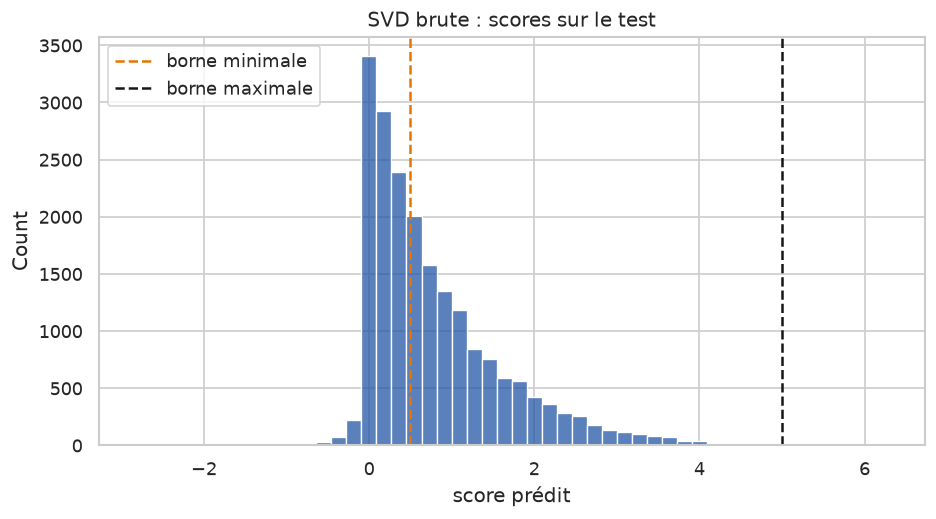

In [10]:
held_users = test_set[:, 0].astype(int)
held_items = test_set[:, 1].astype(int)
held_raw_scores = pred_svd_raw[held_users, held_items]
print(pd.Series(held_raw_scores).describe(percentiles=[.01, .1, .5, .9, .99]))
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(held_raw_scores, bins=50, ax=ax, color="#2457A7")
ax.axvline(.5, color="#E87500", linestyle="--", label="borne minimale")
ax.axvline(5, color="#161616", linestyle="--", label="borne maximale")
ax.set(title="SVD brute : scores sur le test", xlabel="score prédit")
ax.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tp1_distribution_svd_brute.png", dpi=180)
plt.show()

## Question 1.o - Centrage par utilisateur

On soustrait la moyenne de chaque utilisateur aux seules notes connues, puis on
la rajoute après prédiction :

$$\hat r_{ui}=\bar r_u + \widehat{(r_{ui}-\bar r_u)}.$$

In [11]:
del item_products, pred_user_raw, pred_item_raw
gc.collect()
centered_utility, user_means = center_observed(utility, axis=1)
c_user_products, c_item_products, c_inv_user, c_inv_item = get_similarities(centered_utility)
c_user_idx10, c_user_w10 = precompute_topk(c_user_products, c_inv_user, 10)
c_item_idx10, c_item_w10 = precompute_topk(c_item_products, c_inv_item, 10)
pred_user_centered = predict_user_topk_matrix(
    centered_utility, train_mask, c_user_idx10, c_user_w10, user_means)
pred_item_centered = predict_item_topk_matrix(
    centered_utility, train_mask, c_item_idx10, c_item_w10, user_means)
centered_cf_metrics = {
    "User-based centré k=10": rmse_from_matrix(test_set, pred_user_centered),
    "Item-based centré k=10": rmse_from_matrix(test_set, pred_item_centered),
}
centered_cf_ndcg = {
    "User-based centré k=10": ndcg_at_k_from_matrix(test_set, pred_user_centered, train_mask, 10),
    "Item-based centré k=10": ndcg_at_k_from_matrix(test_set, pred_item_centered, train_mask, 10),
}

start = time.perf_counter()
centered_svd = svd_decompose(centered_utility)
centered_svd_time = time.perf_counter() - start
centered_svd_rmse = {
    rank: rmse_from_matrix(test_set, svd_predict(centered_svd, rank, user_means))
    for rank in ranks
}
best_centered_rank = min(centered_svd_rmse, key=centered_svd_rmse.get)
pred_svd_centered = svd_predict(centered_svd, best_centered_rank, user_means)
centered_svd_ndcg = ndcg_at_k_from_matrix(test_set, pred_svd_centered, train_mask, 10)

summary = pd.DataFrame([
    *({"modèle": n, "RMSE": v, "NDCG@10": raw_cf_ndcg[n]} for n, v in raw_cf_metrics.items()),
    *({"modèle": n, "RMSE": v, "NDCG@10": centered_cf_ndcg[n]} for n, v in centered_cf_metrics.items()),
    {"modèle": f"SVD brute (rang {best_raw_rank})", "RMSE": raw_svd_rmse[best_raw_rank], "NDCG@10": raw_svd_ndcg},
    {"modèle": f"SVD centrée (rang {best_centered_rank})", "RMSE": centered_svd_rmse[best_centered_rank], "NDCG@10": centered_svd_ndcg},
]).sort_values("RMSE")
display(summary)
print(f"Temps SVD centrée : {centered_svd_time:.2f} s")

Temps SVD centrée : 1.36 s


,modèle,RMSE,NDCG@10
5,SVD centrée (rang 5),0.916248,0.131640
3,Item-based centré k=10,0.943507,0.025942
2,User-based centré k=10,0.956349,0.023651
1,Item-based k=10,0.997426,0.027532
0,User-based k=10,1.060962,0.023340
4,SVD brute (rang 10),2.787438,0.243278


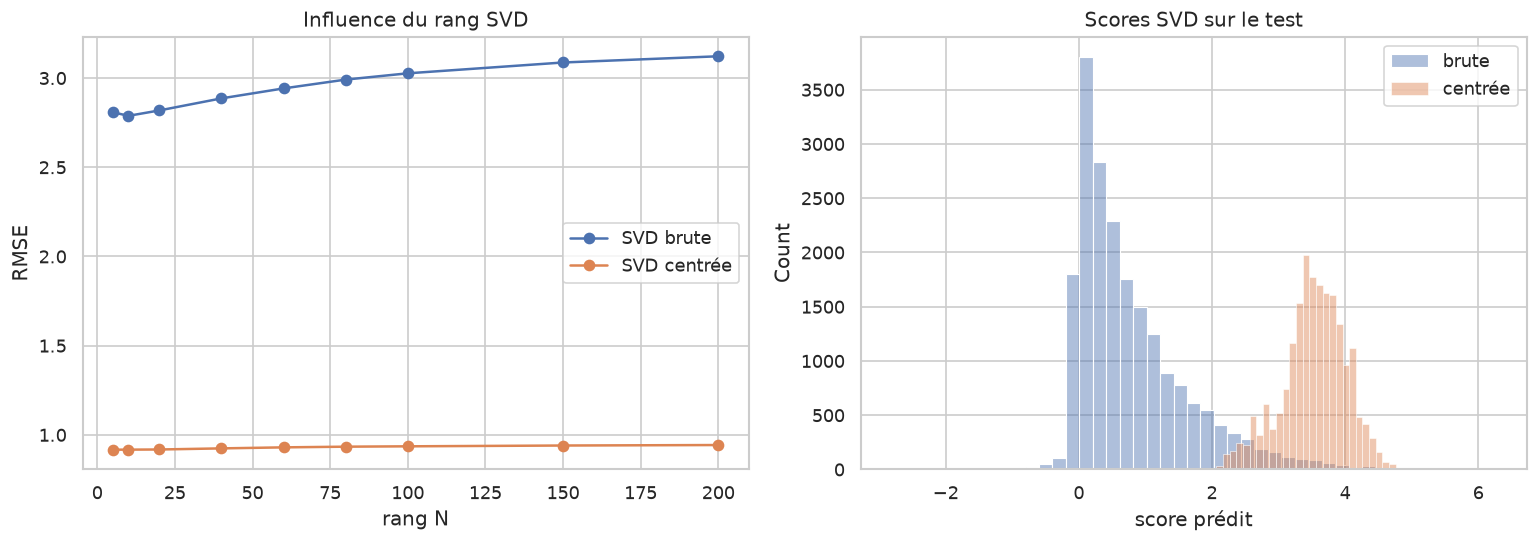

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].plot(ranks, [raw_svd_rmse[r] for r in ranks], marker="o", label="SVD brute")
axes[0].plot(ranks, [centered_svd_rmse[r] for r in ranks], marker="o", label="SVD centrée")
axes[0].set(title="Influence du rang SVD", xlabel="rang N", ylabel="RMSE")
axes[0].legend()
held_centered_scores = pred_svd_centered[held_users, held_items]
sns.histplot(held_raw_scores, bins=45, alpha=.45, label="brute", ax=axes[1])
sns.histplot(held_centered_scores, bins=45, alpha=.45, label="centrée", ax=axes[1])
axes[1].set(title="Scores SVD sur le test", xlabel="score prédit")
axes[1].legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tp1_comparaison_svd.png", dpi=180)
plt.show()

metrics_tp1 = {
    "dataset": {"ratings": len(ratings), "users": utility.shape[0], "items": utility.shape[1], "train_density_pct": float(density)},
    "raw_cf_rmse": {k: float(v) for k, v in raw_cf_metrics.items()},
    "raw_cf_ndcg10": {k: float(v) for k, v in raw_cf_ndcg.items()},
    "centered_cf_rmse": {k: float(v) for k, v in centered_cf_metrics.items()},
    "centered_cf_ndcg10": {k: float(v) for k, v in centered_cf_ndcg.items()},
    "svd_raw": {"best_rank": int(best_raw_rank), "rmse": float(raw_svd_rmse[best_raw_rank]), "ndcg10": float(raw_svd_ndcg), "curve": {str(k): float(v) for k, v in raw_svd_rmse.items()}},
    "svd_centered": {"best_rank": int(best_centered_rank), "rmse": float(centered_svd_rmse[best_centered_rank]), "ndcg10": float(centered_svd_ndcg), "curve": {str(k): float(v) for k, v in centered_svd_rmse.items()}},
}
(OUTPUT_DIR / "metrics_tp1.json").write_text(
    json.dumps(metrics_tp1, indent=2, ensure_ascii=False), encoding="utf-8")

## Conclusion TP1

RMSE et NDCG répondent à deux objectifs différents. La SVD brute confond zéros
manquants et faibles préférences ; le centrage sur les notes observées corrige
une part importante du biais. Le rang optimal doit être choisi sur validation.